In [5]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
import cairosvg
import io


import pickle
import matplotlib.pyplot as plt
# import torch
import numpy as np
# from dqn import MolDQN
from rdkit.Chem import QED
# from beautifultable import BeautifulTable, BTRowCollection
# from prettytable import PrettyTable

import pandas as pd
import pickle
# import joblib
# from molbert.utils.featurizer.molbert_featurizer import MolBertFeaturizer

from rdkit import RDConfig
import os
import sys


from rdkit.DataManip.Metric import GetTanimotoDistMat
from rdkit.DataManip.Metric import GetTanimotoSimMat

IPythonConsole.ipython_useSVG=True
import random

Chem.MolFromSmiles('CN(C)c1cncc(O)c1N(C)C')

def mol_to_png(mol, file_name, h = None, l = '', width=300, height=200):
    full_path = f'./Results/{file_name}.png'
    # Render high resolution molecule
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    drawer.DrawMolecule(mol, highlightAtoms=h, legend=l)
    drawer.FinishDrawing()
    cairosvg.svg2png(bytestring=drawer.GetDrawingText().encode(), write_to=full_path)

def draw_with_same(mol1, mol2, file_name, l = ''):
    mcs = rdFMCS.FindMCS([mol1,mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    
    if mol1.GetNumAtoms() <= mol2.GetNumAtoms():
        
        match2 = mol2.GetSubstructMatch(mcs_mol)
        target_atm2 = []
        for atom in mol2.GetAtoms():
            # if atom.GetIdx() not in match2:
            if atom.GetIdx() in match2:
                target_atm2.append(atom.GetIdx())
        mol_to_png(mol2, file_name, target_atm2, l)
    else:
        pass
        # match1 = mol1.GetSubstructMatch(mcs_mol)
        # r = Chem.RWMol(mol1)
        # r.BeginBatchEdit()
        # for atom in mol1.GetAtoms():
        #     if atom.GetIdx() in match1:
        #         r.RemoveAtom(atom.GetIdx())
        # r.CommitBatchEdit()
        # rs = Chem.MolToSmiles(r)
        # m2s = Chem.MolToSmiles(mol2)
        # ns = f'{m2s}.{rs}'
        # nm = Chem.MolFromSmiles(ns)
        
        # mcs2 = rdFMCS.FindMCS([nm,mol2])
        # mcs_mol2 = Chem.MolFromSmarts(mcs2.smartsString)
        # match3 = nm.GetSubstructMatch(mcs_mol2)
        # target_atmn = []
        # for atom in nm.GetAtoms():
        #     if atom.GetIdx() not in match3:
        #         target_atmn.append(atom.GetIdx())
        # mol_to_png(nm, file_name, target_atmn, l)

s = 'COc1cnc(OC)c(O)c1'
mol = Chem.MolFromSmiles(s)
s2 = 'CCOc1cnc(OC)c(O)c1'
mol2 = Chem.MolFromSmiles(s2)
draw_with_same(mol, mol2, 'example_test')


def get_cs(mol, nm = [], aid = 0):
    c_add = (0.8, 0, 0)
    c_mod = (0, 0.8, 0.8)
    atom_cols = {}
    for i in nm:
        if i == aid:
            atom_cols[i] = c_add
        else:
            atom_cols[i] = c_mod
    return atom_cols
    
def mol_to_png2(mol, file_name, h = [], aid = 0, l = '', width=1200, height=600):
    full_path = f'./Results/{file_name}.png'
    # Render high resolution molecule
    # for aid, a in enumerate(mol.GetAtoms()):
        # print(aid)
        # a.SetProp('atomNode
    
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    # drawer.drawOptions().addAtomIndices = True
    drawer.DrawMolecule(mol, highlightAtoms=h, highlightAtomColors=get_cs(mol, h, aid),legend=l)
    drawer.FinishDrawing()

    # Export to pdf
    cairosvg.svg2png(bytestring=drawer.GetDrawingText().encode(), write_to=full_path)

# mol = Chem.MolFromSmiles('c0ccccc0CC')
# mol_to_png(mol, 'example_imf_1', h = [0,1,3,4,5,6,7], aid = 7)
# mol = Chem.MolFromSmiles('CN(C)CCCN(C(=O)C1COc2ccccc2O1)c1nc2cc3c(cc2s1)OC(=N)O3')
# mol_to_png(mol, 'example_imf_2', h = [30,29,28,31,24,23,25,26,22,21], aid = 30)

import glob
def read_pickles(reg):
    paths = glob.glob(f'./Experiments/{reg}')
    # files = [open(p, 'rb') for p in paths]
    # return [pickle.load(f) for f in files]
    rt = []
    for p in paths:
        f = open(p, 'rb')
        rt.append(pickle.load(f))
        f.close()
    return rt


<class 'dict'>
top
<class 'list'>
last
<class 'list'>
-------------------------------------
CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1
CC(C)(C)c1cc(O)c2occ(CC(=O)Nc3ccccc3F)c2c1
CC(C)(C)c1cc(O)c2occ(CC(=O)n3c4ccc3c(F)c4)c2c1
CC(C(=O)n1c2ccc1c(F)c2)c1coc2c(O)cc(C(C)(C)C)cc12
CC(C(=O)n1c2ccc1c(F)c2)c1coc2c(O)cc(C3(C)CC3)cc12
Cc1cc2cc(F)c1n2C(=O)C(C)c1coc2c(O)cc(C3(C)CC3)cc12
Cc1cc2cc(F)c1n2C(=O)C(C)c1c(N)oc2c(O)cc(C3(C)CC3)cc12
CCc1cc2cc(F)c1n2C(=O)C(C)c1c(N)oc2c(O)cc(C3(C)CC3)cc12
CCc1cc2cc(F)c1n2C(=O)C(C=N)c1c(N)oc2c(O)cc(C3(C)CC3)cc12
C=CC1(c2cc(O)c3oc(N)c(C(C=N)C(=O)n4c5cc(F)c4c(CC)c5)c3c2)CC1
C=CC1(c2cc(O)c3oc(NO)c(C(C=N)C(=O)n4c5cc(F)c4c(CC)c5)c3c2)CC1
C=CC1(c2cc(O)c3oc(NO)c(C(C=N)C(=O)n4c5ccc4c(CC)c5)c3c2)CC1
CC=CC1(c2cc(O)c3oc(NO)c(C(C=N)C(=O)n4c5ccc4c(CC)c5)c3c2)CC1
CC=CC1(c2cc(O)c3oc4c(c3c2)C(C(=O)n2c3ccc2c(CC)c3)C(=N)N4O)CC1
CCc1cc2ccc1n2C(=O)C1C(=N)N(O)c2oc3c(O)cc(C4(C=CCN)CC4)cc3c21
CC(=N)c1cc2ccc1n2C(=O)C1C(=N)N(O)c2oc3c(O)cc(C4(C=CCN)CC4)cc3c21
CC(=N)c1cc2ccc1n2C(=O)C1C(=N)N(

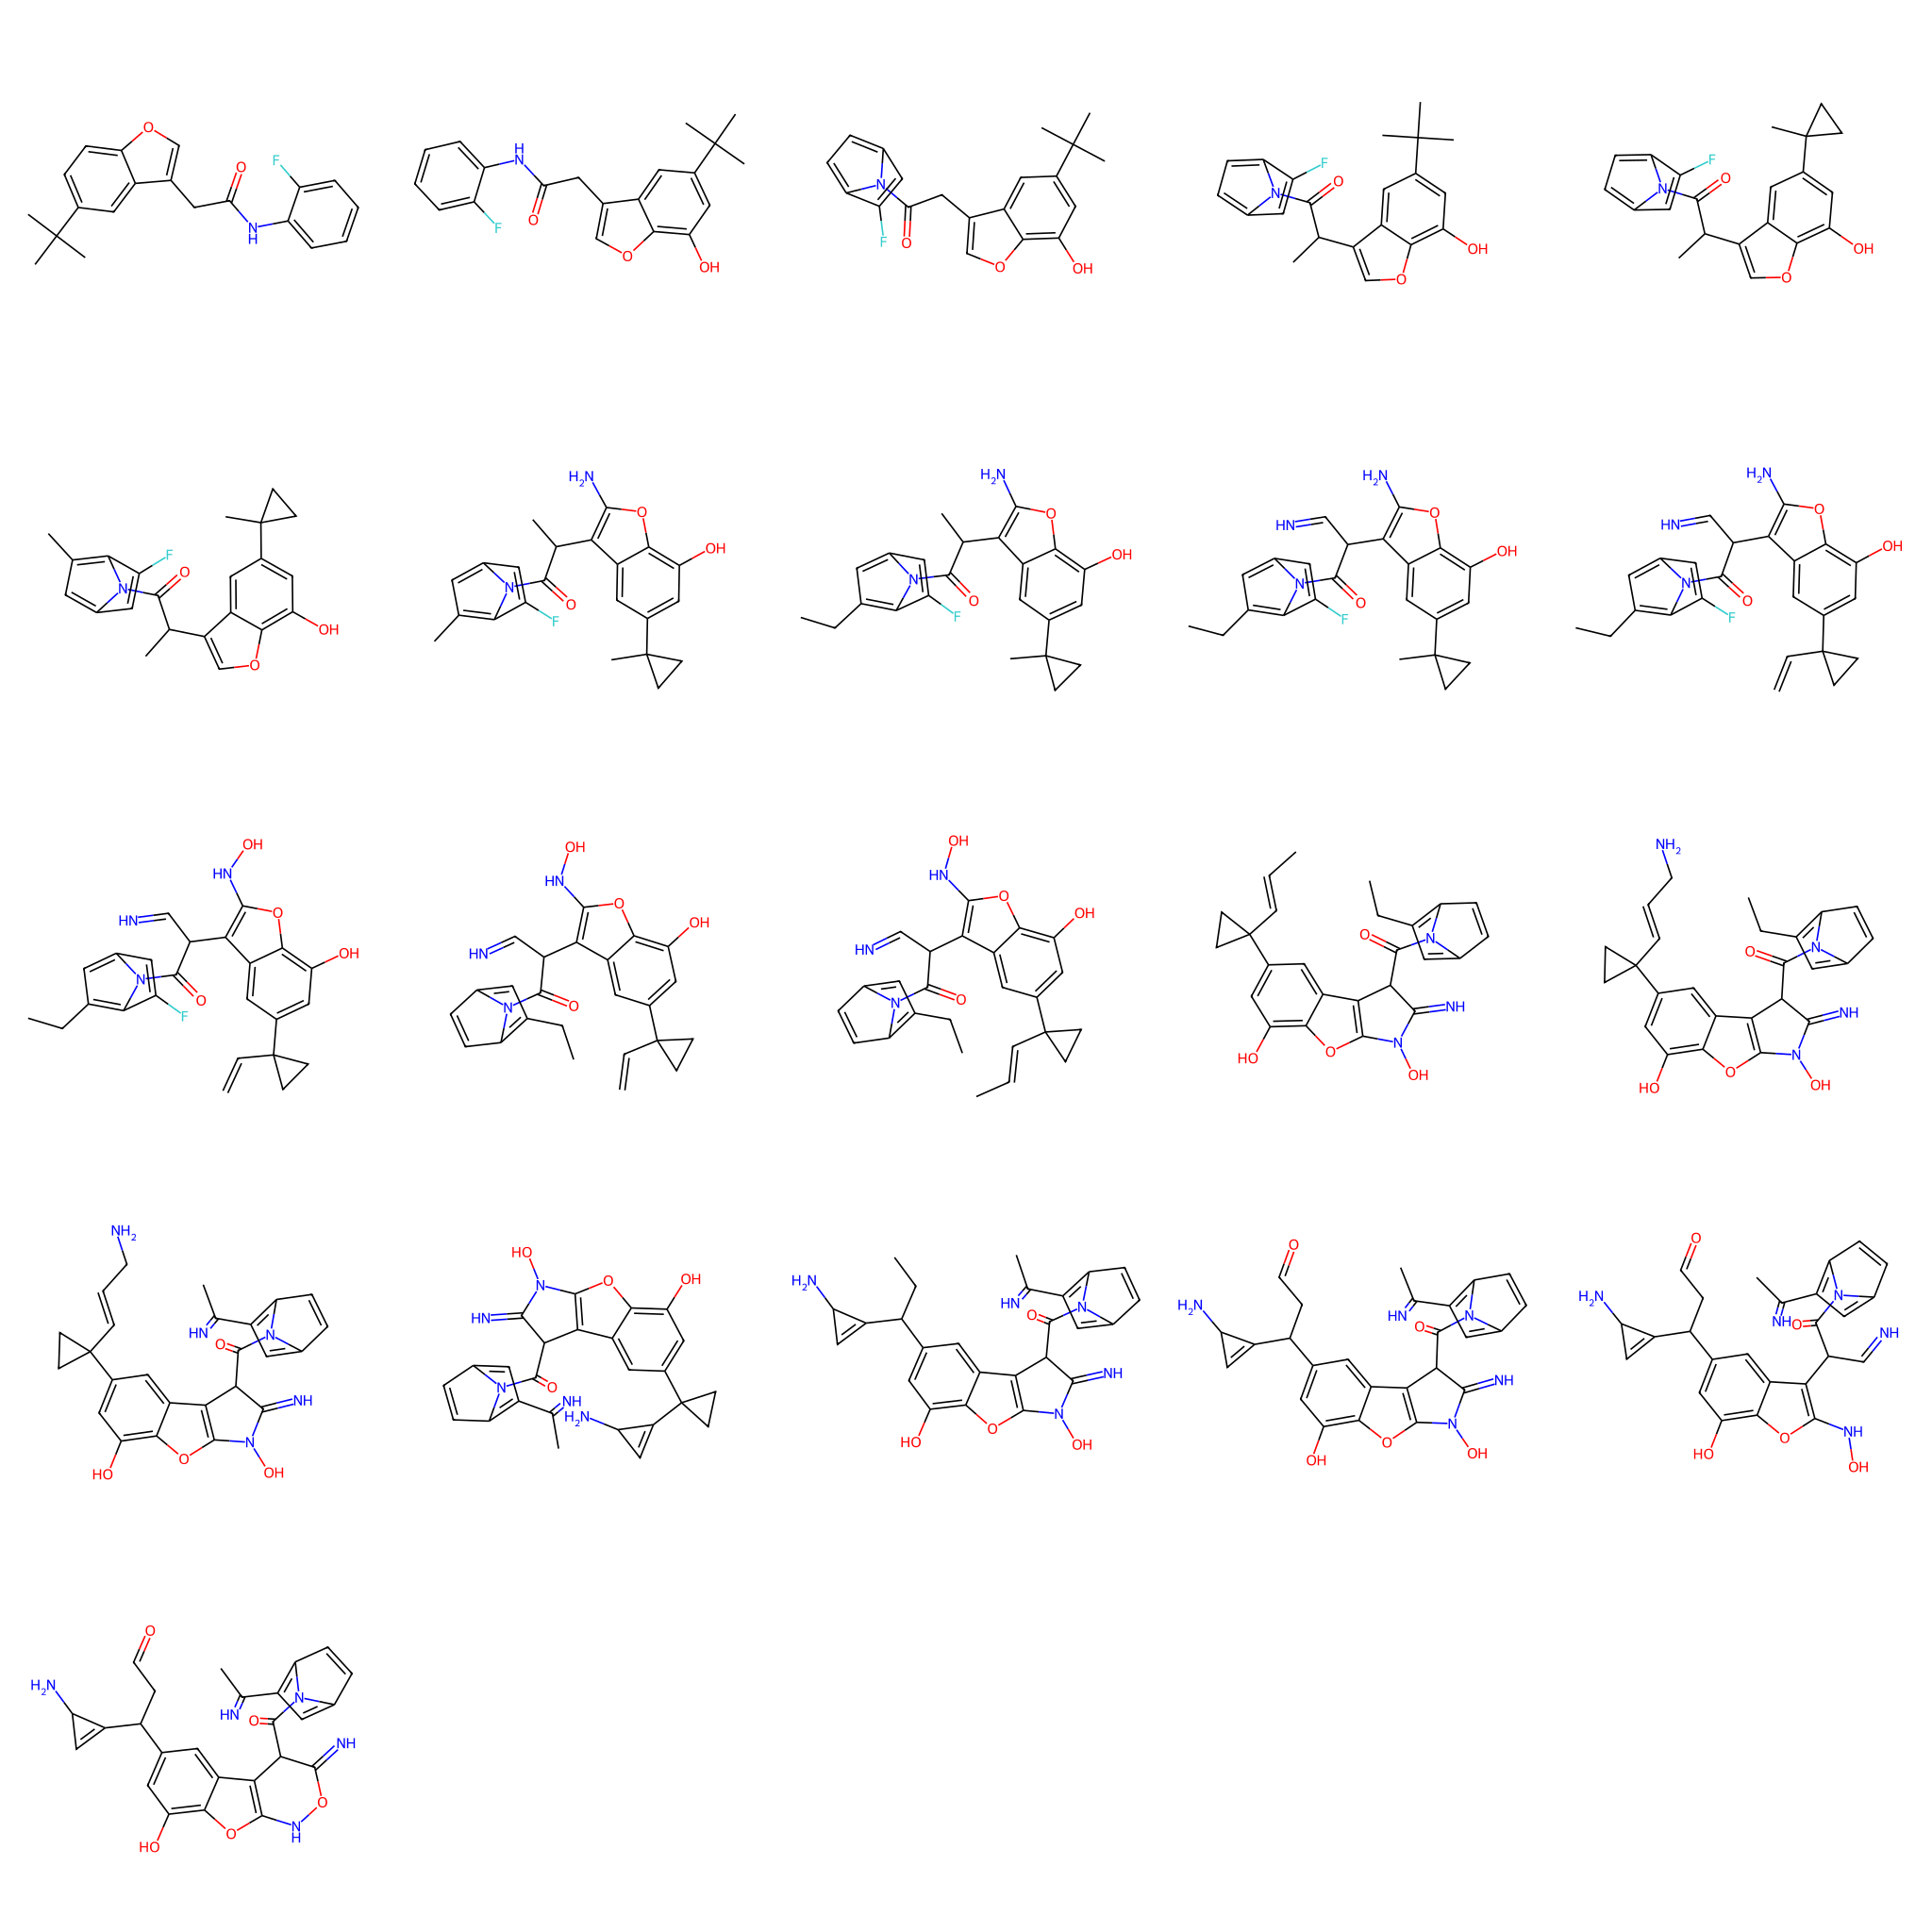

In [19]:

        
p = read_pickles('maple_qedtest2_0_0_path*')
print(type(p[0]))
for k, v in p[0].items():
    print(k)
    print(type(v))

print('-------------------------------------')
tem = p[0]['last'][-1]
mols, rewards = tem
path = mols[0]
rewards = rewards['reward'][0]
# print(path)
# path[0]
for i, mol in enumerate(path):
    # print(mol)
    s = Chem.MolToSmiles(mol)
    print(s)
    mol_to_png(m, f'maple_qed_{i}')
Draw.MolsToGridImage(path, subImgSize=(500, 500), molsPerRow=5)

<class 'dict'>
top
<class 'list'>
last
<class 'list'>
-------------------------------------
CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1
CC1(c2ccc3occ(CC(=O)Nc4ccccc4F)c3c2)CC1
O=C(Cc1coc2ccc(C3CC3)cc12)Nc1ccccc1F
Cc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F
CCCCCc1cccc(NC(=O)Cc2coc3ccc(C4CC4)cc23)c1F


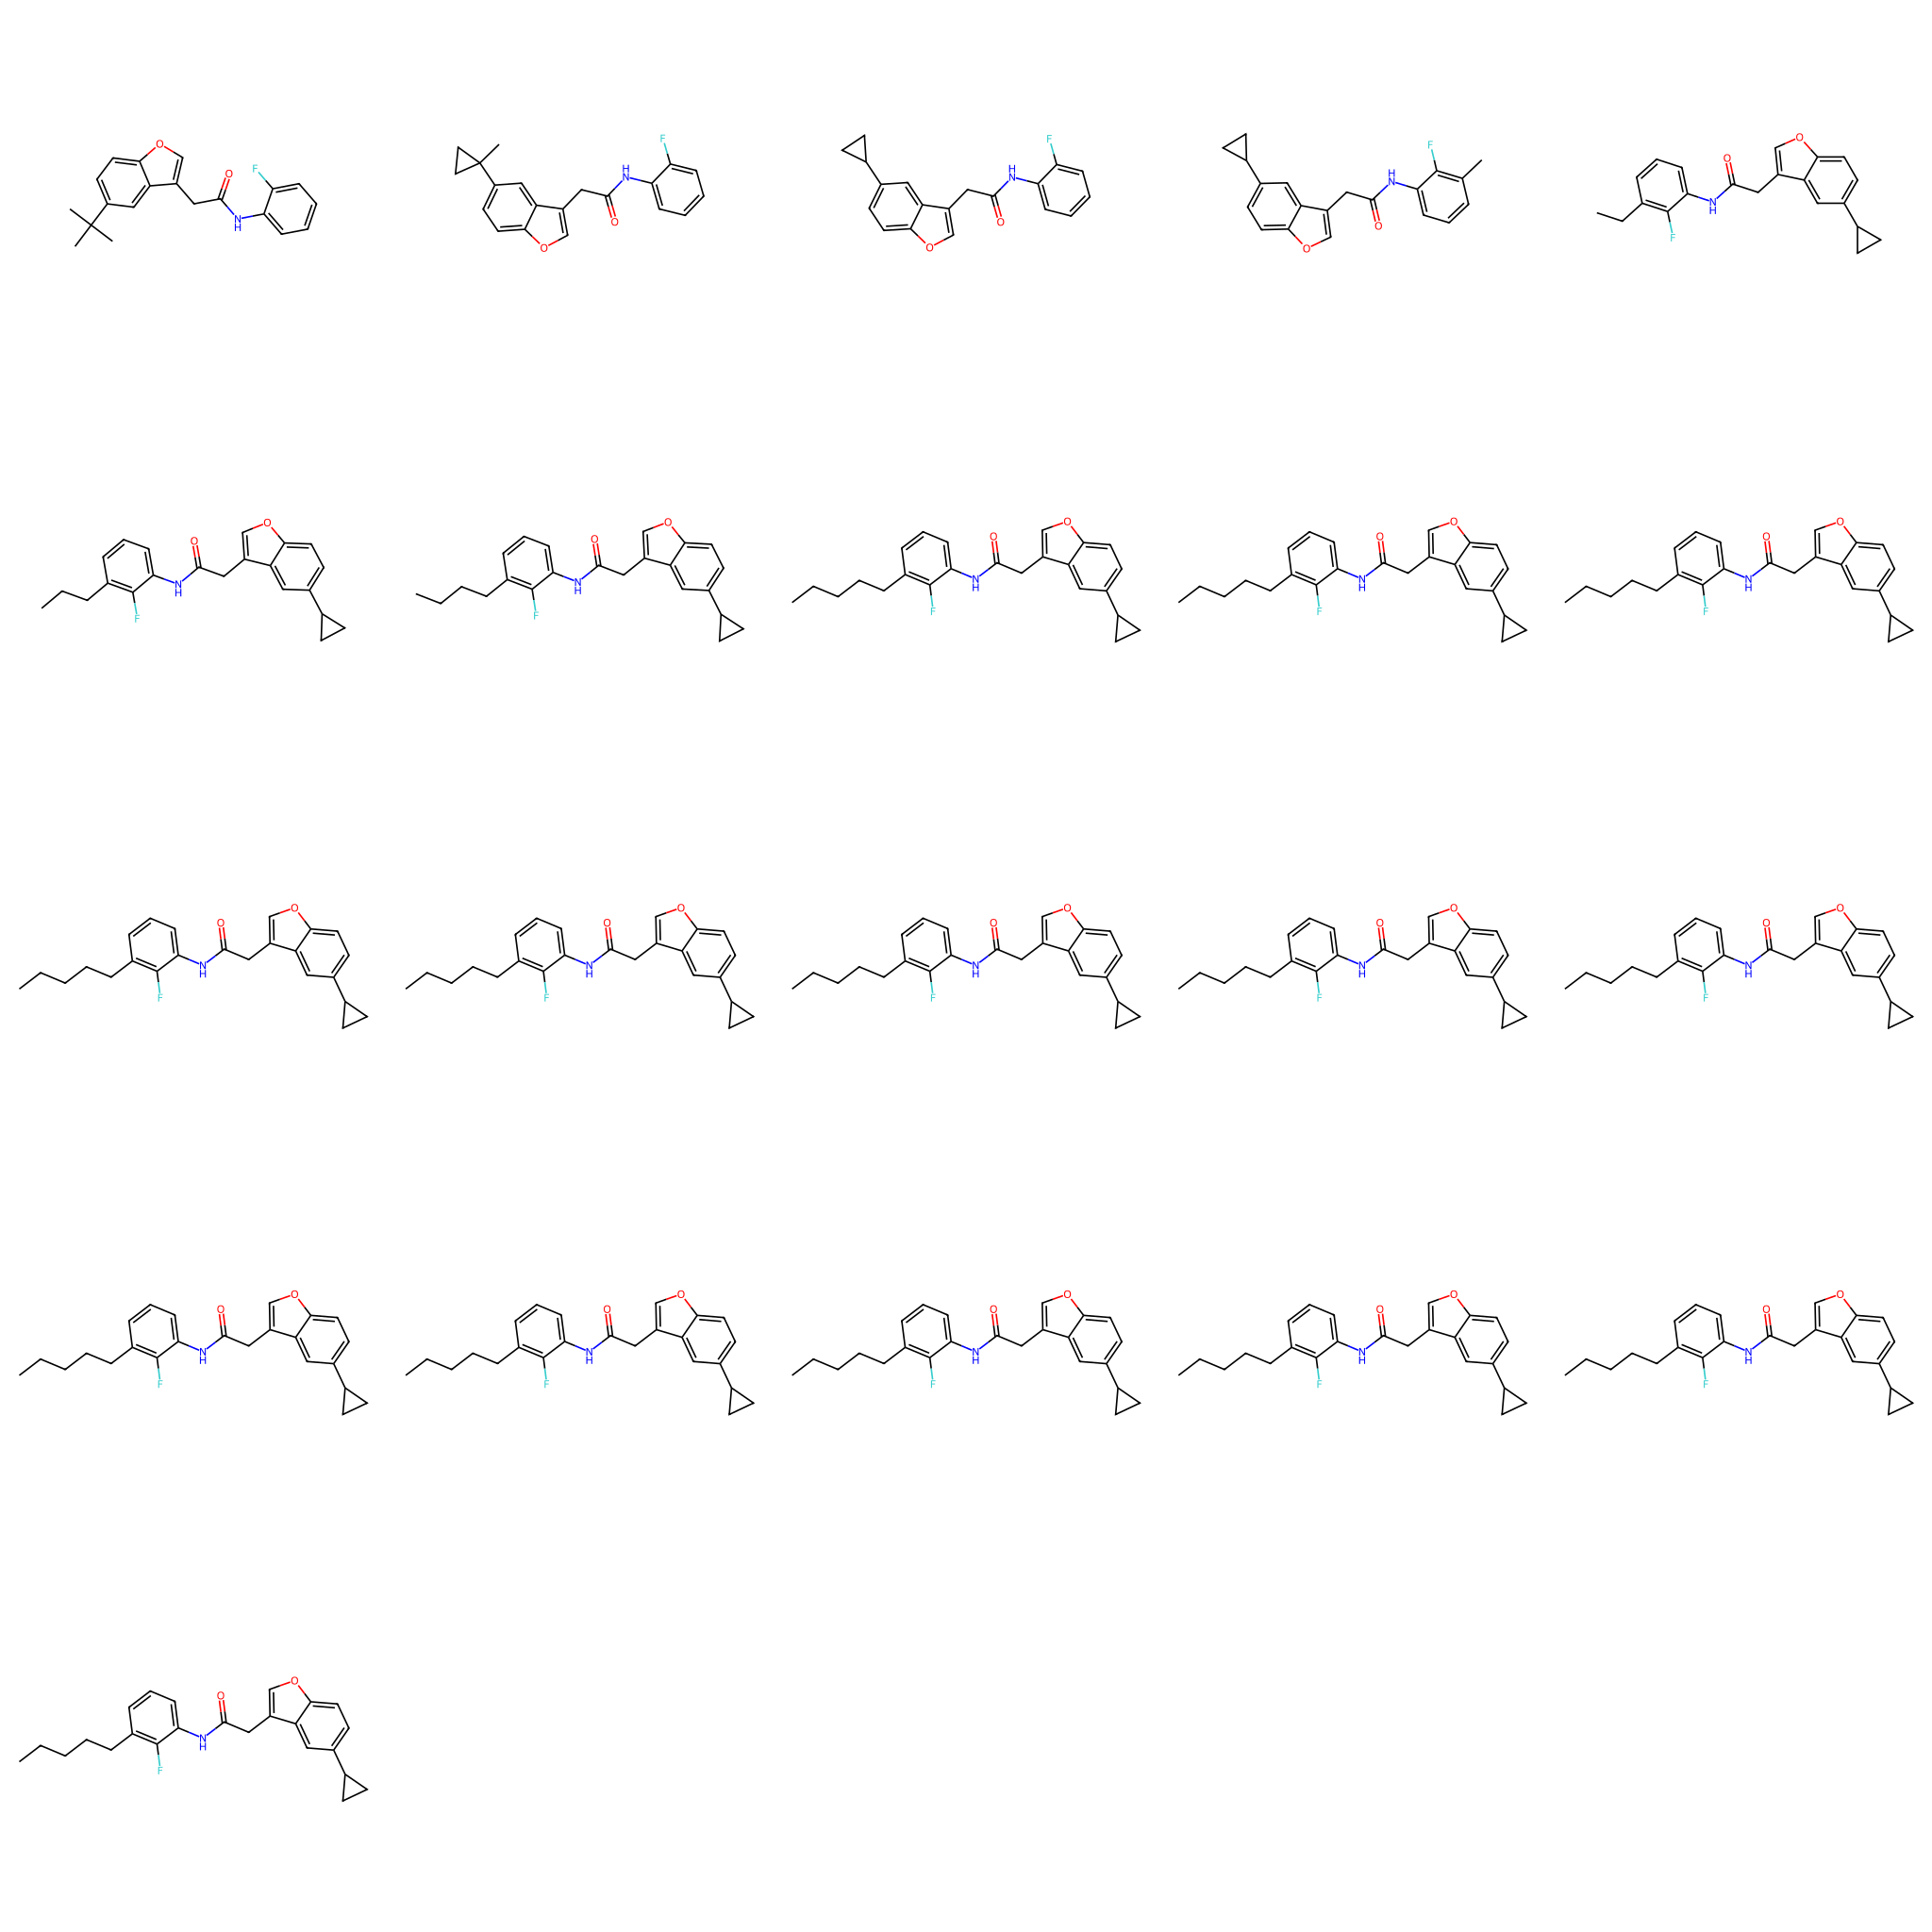

In [20]:
p = read_pickles('ZincQED_1_0_path*')
print(type(p[0]))
for k, v in p[0].items():
    print(k)
    print(type(v))

print('-------------------------------------')
tem = p[0]['last'][-1]
mols, rewards = tem
path = mols[0]
rewards = rewards['reward'][0]
# print(path)
# path[0]
for i, mol in enumerate(path):
    # print(mol)
    s = Chem.MolToSmiles(mol)
    print(s)
    mol_to_png(m, f'cypress_qed_{i}')
Draw.MolsToGridImage(path, subImgSize=(500, 500), molsPerRow=5)